In [1]:
using LinearAlgebra
using Plots
using ITensors
using ITensorMPS
include("../../src/TensorBinding.jl") # if you have the package installed, you can directly do using TensorBinding
using .TensorBinding

---
## 1. Exciton Hamiltonians

An exciton is a correlated electron-hole pair. In the quantics representation
the two-particle Hilbert space is encoded on a `2L`-qubit chain: odd sites store
the electron position qubits and even sites store the hole position qubits.

The exciton Hamiltonian is
$$H_{\rm exc} = H_e \otimes I_h - I_e \otimes H_h - V_{eh},$$
where $V_{eh}(r_e, r_h) = U(r_e,r_h)$ is a Hubbard-type electron-hole interaction
that can be modulated in space.

This notebook illustrates three exciton spectral calculations:

1. **Hamiltonian construction**: build a 1D electron-hole Hamiltonian with an
   APSOS-style modulated type-I confinement profile.
2. **Real-space LDOS**: compute
   $$A(X,\omega)=\langle X,X|\delta(\omega-H_{\rm exc})|X,X\rangle$$
   using MPS-mode KPM, which propagates one reference state instead of storing a
   full MPO Chebyshev list.
3. **Momentum-space bands**: QFT-conjugate the exciton MPO and compute the
   coherent pair spectrum
   $$A(q,\omega)$$
   using `get_exciton_bands`.

The incoherent electron-hole continuum can also be estimated with
`get_exciton_continuum`, but it is substantially slower because it runs several
MPS-KPM trace probes for every total momentum. For that reason the continuum
calculation is commented out in the bands cell; the old output figure is left in
the notebook as a reference.

In [2]:
# 1D electron + hole on a chain; APSOS-style modulated type-I confinement
L_exc      = 5          # 2^5 = 32 sites per particle
t_exc      = -1.0
U_exc      = 6.0        # contact attraction strength
V0_exc     = 1.5        # confinement scale
scale_exc  = 10.0
maxdim_exc = 100

N_sites_exc = 2^L_exc

function Vx_exc(x; V0=V0_exc, N=N_sites_exc)

    b = sqrt(3)*N/10
    k = 2*pi/b

    return V0*(1 + 0.2*(cos(k*x)))
end

H_exc = TensorBinding.exciton_hamiltonian("chain_1d", t_exc, x -> U_exc;
    L       = L_exc,
    on_site = Vx_exc,
    scale   = scale_exc,
    maxdim  = maxdim_exc)
println(H_exc)

TBHamiltonian | L=5, N=32 [exciton, D=1024], scale=10.0, maxlinkdim=11 | geometry: 32 sites, 1D | no Tn cache


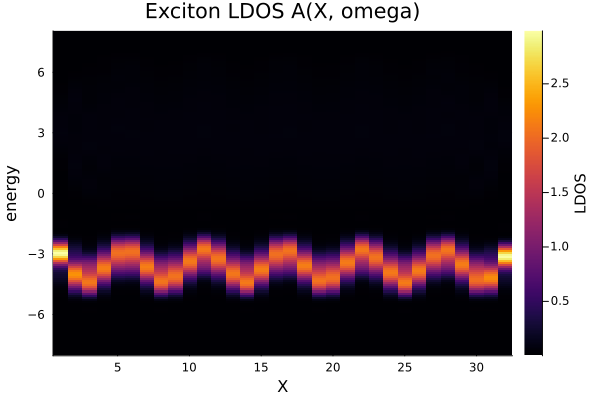

In [3]:
# Exciton LDOS A(X, omega) = <X,X|delta(omega-H)|X,X>
X_list_exc  = collect(1:H_exc.N)
Ncheb_exc   = 80
mdim_exc    = 100
cutoff_exc  = 1e-6
##turn these on if you want to use the HODC kernel instead of Jackson kernel
# m_order_exc = 6
# eta_exc     = 1 / (Ncheb_exc + 1)
omega_exc   = range(-8.0, 8.0; length=160)

ldos_exc_mat = TensorBinding.get_exciton_ldos_spatial(H_exc, Ncheb_exc, omega_exc;
    X_list  = X_list_exc,
    kernel  = :jackson,
    # eta     = eta_exc,
    # m_order = m_order_exc,
    maxdim  = mdim_exc,
    cutoff  = cutoff_exc)

heatmap(X_list_exc, collect(omega_exc), ldos_exc_mat;
        xlabel="X", ylabel="energy", colorbar_title="LDOS",
        title="Exciton LDOS A(X, omega)", color=:inferno)

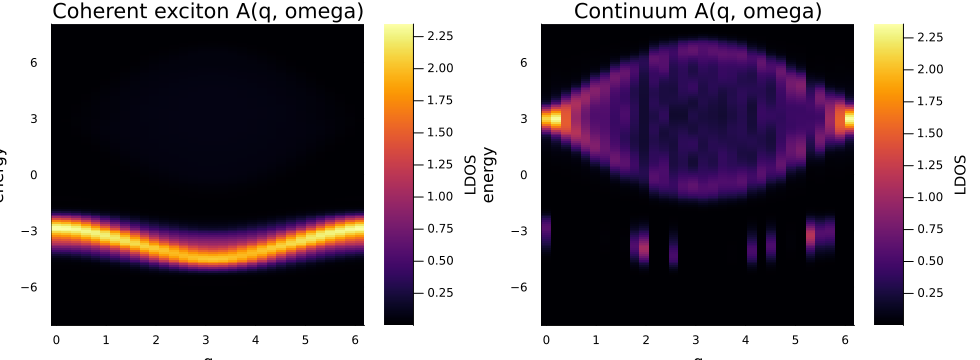

In [ ]:
# Momentum-space exciton LDOS A(q, omega)
Q_list_exc       = collect(1:H_exc_band.N)
q_vals_exc       = 2pi .* (Q_list_exc .- 1) ./ H_exc_band.N
qft_mdim_exc     = 200
N_sample_q_cont  = 4
seed_q_cont_exc   = 42

H_exc_qft = TensorBinding.conjugate_by_qft_exciton(H_exc_band, H_exc_band.mpo;
    tol    = cutoff_exc,
    maxdim = qft_mdim_exc)

A_q_exc = TensorBinding.get_exciton_bands(H_exc_qft, H_exc_band, Ncheb_exc, omega_exc;
    Q_list = Q_list_exc,
    kernel = :jackson,
    # eta     = eta_exc,
    # m_order = m_order_exc,
    maxdim = mdim_exc,
    cutoff = cutoff_exc)

# #uncomment if you want to plot both coherent and continuum exciton LDOS
# A_q_cont = TensorBinding.get_exciton_continuum(H_exc_qft, H_exc_band, Ncheb_exc, omega_exc; 
#     Q_list   = Q_list_exc,
#     N_sample = N_sample_q_cont,
#     seed     = seed_q_cont_exc,
#     kernel   = :jackson,
#     # eta      = eta_exc,
#     # m_order  = m_order_exc,
#     maxdim   = mdim_exc,
#     cutoff   = cutoff_exc)

p_Aq_exc = heatmap(q_vals_exc, collect(omega_exc), A_q_exc;
    xlabel="q", ylabel="energy", colorbar_title="LDOS",
    title="Coherent exciton A(q, omega)", color=:inferno)

# p_Aq_cont = heatmap(q_vals_exc, collect(omega_exc), A_q_cont; #uncomment if you want to plot both coherent and continuum exciton LDOS
#     xlabel="q", ylabel="energy", colorbar_title="LDOS",
#     title="Continuum A(q, omega)", color=:inferno)

# plot(p_Aq_exc, p_Aq_cont; layout=(1, 2), size=(980, 360)) #uncomment if you want to plot both coherent and continuum exciton LDOS
plot(p_Aq_exc; layout=(1, 1), size=(360, 360))

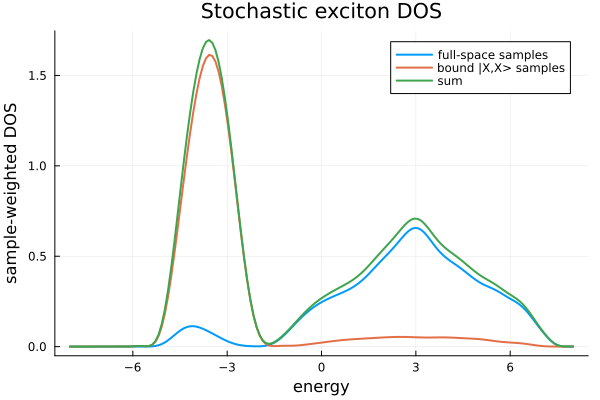

In [6]:
# Stochastic exciton DOS. The CPU helper supports bound-sector enrichment.
N_sample_exc = 20
N_bound_exc  = 12
seed_exc     = 42

dos_full_exc = TensorBinding.get_dos_stochastic(H_exc, Ncheb_exc, omega_exc;
    N_sample      = N_sample_exc,
    N_bound       = 0,
    seed          = seed_exc,
    kernel        = :jackson,
    # eta           = eta_exc,
    # m_order       = m_order_exc,
    normalize     = false,
    dos_weighting = :sample,
    maxdim        = mdim_exc,
    cutoff        = cutoff_exc)

dos_bound_exc = TensorBinding.get_dos_stochastic(H_exc, Ncheb_exc, omega_exc;
    N_sample      = 0,
    N_bound       = N_bound_exc,
    seed          = seed_exc + 1,
    kernel        = :jackson,
    # eta           = eta_exc,
    # m_order       = m_order_exc,
    normalize     = false,
    dos_weighting = :sample,
    maxdim        = mdim_exc,
    cutoff        = cutoff_exc)

dos_total_exc = dos_full_exc .+ dos_bound_exc

plot(collect(omega_exc), [dos_full_exc dos_bound_exc dos_total_exc];
     xlabel="energy", ylabel="sample-weighted DOS",
     title="Stochastic exciton DOS",
     label=["full-space samples" "bound |X,X> samples" "sum"], lw=2)